# Ketone-body handling in Xenium EAE: the genes that are on the 5K panel

The central question of the project is ketone-body metabolism in the EAE spinal cord. The 5K panel has none of the committed ketone enzymes
(*Hmgcs2*, *Hmgcl*, *Oxct1*, *Acat1*, *Aacs*), so this notebook works with what the panel does carry and asks the most that can be asked of it:

| Group | Genes on the panel | What they can tell us |
| --- | --- | --- |
| Ketone enzyme | *Bdh1* | interconverts acetoacetate and BHB in both directions: the only ketone-body enzyme measurable in situ. Its *company* (fatty-acid oxidation genes → ketogenic side; MCT1 → export side) is the clue to its direction |
| Transport | *Slc16a1* (MCT1), *Slc16a3* (MCT4), *Slc5a12* (SMCT2) | who can import / export BHB and lactate |
| Sensing | *Hcar2* (GPR109A, BHB agonist), *Ffar3* (GPR41, BHB antagonist), *Ffar2*, *Nlrp3* (inflammasome inhibited by BHB) | who can respond to BHB |
| Fatty-acid supply | *Cpt1a*, *Cpt1c*, *Cpt2*, *Slc25a20*, *Hadhb*, *Hadh*, *Echs1*, *Acaa2* | the mitochondrial β-oxidation chain that feeds ketogenesis |
| Regulators | *Ppara*, *Ppargc1a*, *Pdk4*, *Fgf21*, *Klb* | the PPARα / FGF21 axis that switches ketogenesis on |
| Acetate | *Acss1*, *Acss2* | the parallel two-carbon fuel |

Design: 107 samples (92 EAE, 15 control), 891k cells, 27 annotated cell types, lesion-distance bins, RR and chronic EAE models with disease-course
labels. Every comparison is pseudobulk per sample (≥20 cells per sample × cell type), Mann–Whitney across samples or paired Wilcoxon within samples.
Sections: (1) who expresses what, (2) EAE vs control in every cell type, by model and by disease course, (3) lesion distance per cell type,
(4) the disease-associated oligodendrocyte and astrocyte states, (5) what *Bdh1* keeps company with (direction), (6) myeloid ketone sensing
(*Hcar2* / *Nlrp3*), (7) spatial neighbourhoods: are *Bdh1*⁺ / *Cpt1a*⁺ astrocytes and *Hcar2*⁺ myeloid cells enriched around DA and *C4b*-high
oligodendrocytes, (8) maps, (9) interpretation.

In [1]:
import os, sys, gc, re, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../scripts")
try:
    from dotenv import load_dotenv
    load_dotenv("../../.env")
except Exception:
    pass
import numpy as np, pandas as pd, scipy.sparse as sp, h5py, scanpy as sc, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
import oligometab as om
from oligometab import EAE5K_KETONE, EAE5K_KETONE_GENES, heat

sc.settings.verbosity = 0
sc.set_figure_params(dpi=80, frameon=False)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 300)

PATH = om.resolve_path("OLIGOMETAB_XENIUM_EAE_H5AD", "../../data/RREAE_5k_raw_only_integration_processed.h5ad")
print("Xenium EAE ->", PATH)
GROUP_OF = {g: k for k, gs in EAE5K_KETONE.items() for g in gs}
KG = EAE5K_KETONE_GENES
KEY = ["Bdh1", "Slc16a1", "Slc16a3", "Slc5a12", "Hcar2", "Ffar3", "Nlrp3", "Cpt1a", "Cpt2", "Hadhb", "Echs1", "Acaa2", "Ppara", "Ppargc1a", "Pdk4", "Fgf21", "Acss2"]
MYELOID = ["Microglia", "Macrophages", "Foamy Mic_Mac", "Activate Mic_Mac 1", "Activated Mic_Mac 2", "Efflux Mic_Mac", "Myeloid cells", "Proliferating microglia", "Mic_AST"]
ASTRO = ["Astrocytes", "DA astrocytes"]
OLIGO = ["Oligodendrocytes", "DA Oligodendrocytes", "Newly formed oligodendrocytes"]
os.makedirs("../../results", exist_ok=True)
R = {}


def save(name, df):
    R[name] = df; df.to_csv(f"../../results/eae5k_ketone_{name}.csv")


def pseudobulk_test(adata, genes, sample_col, group_col, a, b, ct_col="cell_type", cts=None, min_cells=20):
    """Per cell type: pseudobulk per sample, Mann-Whitney a vs b across samples, log2FC of means."""
    cts = cts or list(adata.obs[ct_col].unique())
    sub = adata[adata.obs[ct_col].isin(cts)]
    n = sub.obs.groupby([sample_col, ct_col], observed=True).size().rename("n_cells").reset_index(); n[[sample_col, ct_col]] = n[[sample_col, ct_col]].astype(str)
    pb = om.pseudobulk(sub, genes, sample_col, [ct_col, group_col]).merge(n, on=[sample_col, ct_col]).query("n_cells >= @min_cells")
    rows = []
    for ct in cts:
        p_ct = pb[pb[ct_col] == ct]
        for g in genes:
            ma, mr, p, na, nr = om.group_test(p_ct, g, group_col, a, b)
            rows.append({"cell_type": ct, "gene": g, "group": GROUP_OF.get(g), f"mean_{a}": ma, f"mean_{b}": mr, "log2FC": om.log2fc(ma, mr), "MWU_p": p, f"n_{a}": na, f"n_{b}": nr})
    return pd.DataFrame(rows), pb


def fc_heat(de, title, cts, genes, a, b, vmin=-2, vmax=2):
    d = de.pivot(index="cell_type", columns="gene", values="log2FC").reindex(index=cts, columns=genes); d = d[d.notna().any(axis=1)]
    p = de.pivot(index="cell_type", columns="gene", values="MWU_p").reindex(index=d.index, columns=d.columns)
    heat(d, title, "log2 fold change (* MWU p < 0.05)", fmt=".1f", cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax,
         annot=(d.round(1).astype(str).replace("nan", "") + np.where(p.values < 0.05, "*", "")).values, row_labels=list(d.index))
    return d


def paired_genes(adata, genes, sample_col, mask_a, mask_b, la, lb, min_cells=20):
    df = om.expr_df(adata, genes); smp = adata.obs[sample_col].astype(str).values
    A, B = [], []
    for s_ in np.unique(smp):
        m = smp == s_
        if (m & mask_a).sum() >= min_cells and (m & mask_b).sum() >= min_cells:
            A.append(df[m & mask_a].mean()); B.append(df[m & mask_b].mean())
    A, B = pd.DataFrame(A), pd.DataFrame(B)
    return pd.DataFrame([{"gene": g, "group": GROUP_OF.get(g), f"mean_{la}": A[g].mean(), f"mean_{lb}": B[g].mean(), "log2FC": om.log2fc(A[g].mean(), B[g].mean()),
                          "n_samples": len(A), "frac_samples_up": float((A[g] > B[g]).mean()) if len(A) else np.nan,
                          "wilcoxon_p": stats.wilcoxon(A[g], B[g]).pvalue if len(A) >= 3 and not np.allclose(A[g], B[g]) else np.nan} for g in df.columns]).set_index("gene")


def bin_order(values):
    return sorted([v for v in values if str(v) not in ("nan", "None")], key=lambda b: (1, 0) if str(b).startswith(">") else (0, int(re.search(r"(\d+)", str(b)).group(1))))

Xenium EAE -> /Volumes/jamboree/RRMap/data/RREAE_5k_raw_only_integration_processed.h5ad


In [2]:
from anndata import AnnData
from anndata.experimental import read_elem
with h5py.File(PATH, "r") as f:
    obs = read_elem(f["obs"]); var = read_elem(f["var"])
    shape = tuple(f["X"].attrs["shape"])
    X = sp.csr_matrix((f["X/data"][:].astype(np.float32), f["X/indices"][:], f["X/indptr"][:]), shape=shape)
    spatial = f["obsm/spatial"][:]
obs.index = obs.index.astype(str); var.index = var.index.astype(str)
ad = AnnData(X=X, obs=obs, var=var); ad.obsm["spatial"] = spatial; ad.obs_names_make_unique(); del X, obs, var
ad.obs["cell_type"] = ad.obs["cell_type"].astype(str).replace({"DA oligodendrocytes": "DA Oligodendrocytes", "Astrocyte": "Astrocytes"})
sc.pp.normalize_total(ad, target_sum=1e4); sc.pp.log1p(ad)
present = om.present(ad, KG); print("on panel:", present, "| not on panel:", om.missing(ad, KG))
KG = present; KEY = [g for g in KEY if g in KG]
for c in ["condition", "model", "course", "lesion_density_call"]:
    print(c, ad.obs[c].astype(str).value_counts().to_dict())
meta = ad.obs.groupby("sample_name", observed=True).agg(condition=("condition", "first"), model=("model", "first"), course=("course", "first"), n_cells=("condition", "size"))
meta["frac_lesion"] = ad.obs.groupby("sample_name", observed=True)["lesion_density_call"].apply(lambda s: (s.astype(str) != "non_lesion").mean())
print(meta.groupby(["condition", "model", "course"], observed=True).size())
vc = ad.obs["cell_type"].value_counts(); CTS = [c for c in vc.index if vc[c] >= 1500 and c != "unclear"]
P = om.pathway_scores(ad, {"FA supply for ketogenesis": ["Cpt1a", "Cpt2", "Slc25a20", "Hadhb", "Hadh", "Echs1", "Acaa2"]}, min_genes=3)
ad.obs["FA_supply_score"] = P["FA supply for ketogenesis"].values

on panel: ['Bdh1', 'Slc16a1', 'Slc16a3', 'Slc5a12', 'Hcar2', 'Ffar3', 'Ffar2', 'Nlrp3', 'Cpt1a', 'Cpt1c', 'Cpt2', 'Slc25a20', 'Hadhb', 'Hadh', 'Echs1', 'Acaa2', 'Ppara', 'Ppargc1a', 'Pdk4', 'Fgf21', 'Klb', 'Acss1', 'Acss2'] | not on panel: []
condition {'EAE': 796387, 'CONTROL': 95434}


model {'RR': 619519, 'Chronic': 272302}
course {'peak III': 111134, 'peak I': 108105, 'monophasic': 95288, 'chronic long': 79010, 'remitt I': 73216, 'peak II': 71858, 'chronic peak': 67419, 'PLP CFA': 59431, 'early onset': 58818, 'onset II ': 39864, 'onset I': 37400, 'MOG CFA': 36003, 'non symptomatic': 31052, 'remitt II': 23223}
lesion_density_call {'non_lesion': 830869, 'lesion': 60952}


condition  model    course         
CONTROL    Chronic  MOG CFA             6
           RR       PLP CFA             9
EAE        Chronic  chronic long       10
                    chronic peak        6
                    early onset         8
                    non symptomatic     6
           RR       monophasic         12
                    onset I             6
                    onset II            6
                    peak I             10
                    peak II             8
                    peak III            9
                    remitt I            8
                    remitt II           3
dtype: int64


## 1. Who expresses what

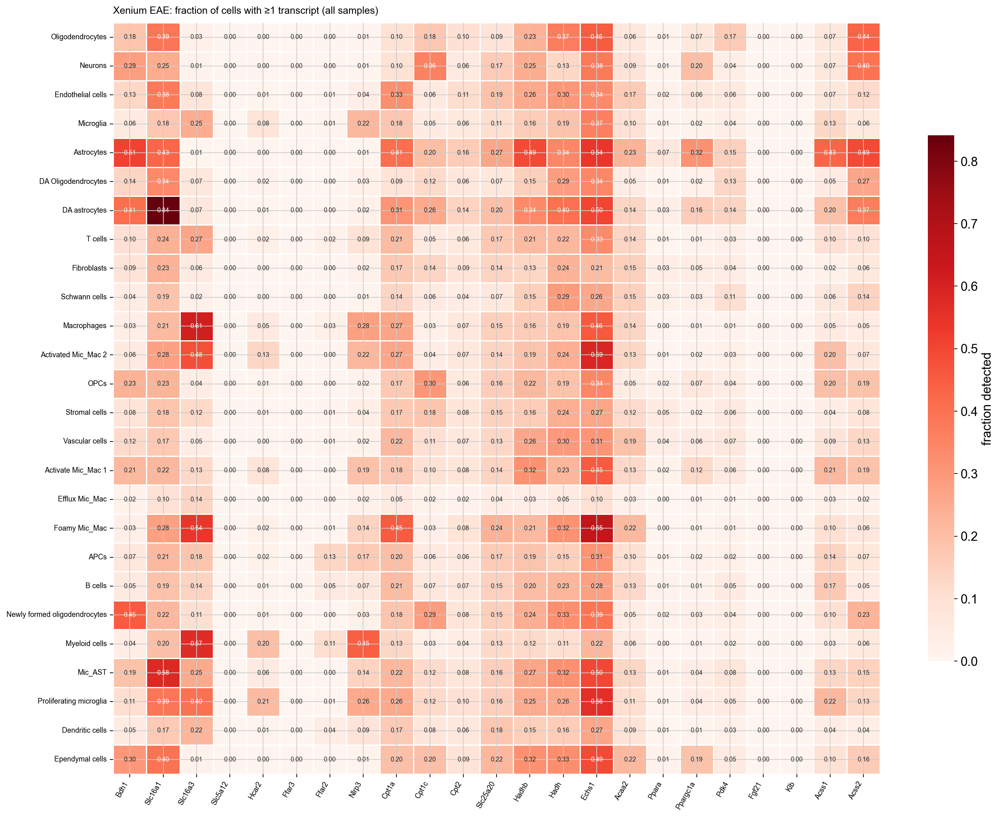

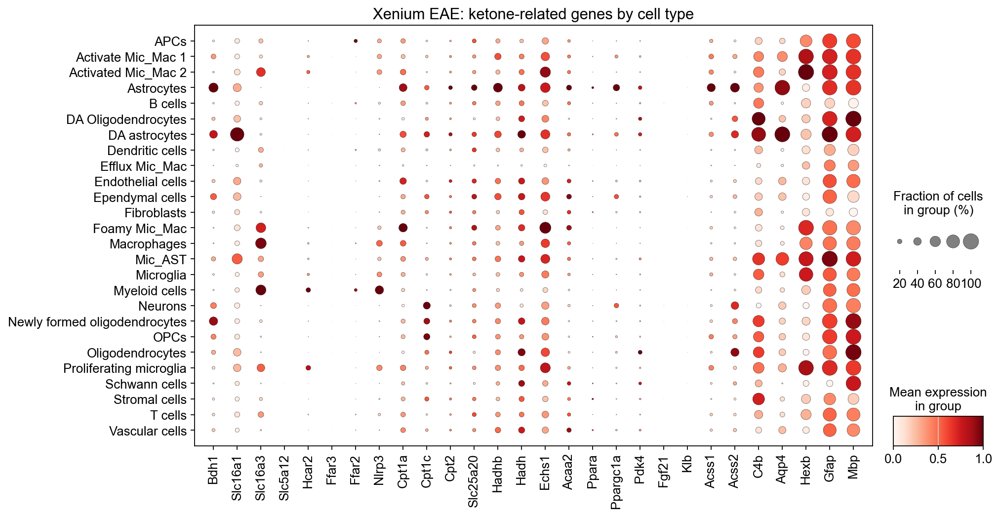

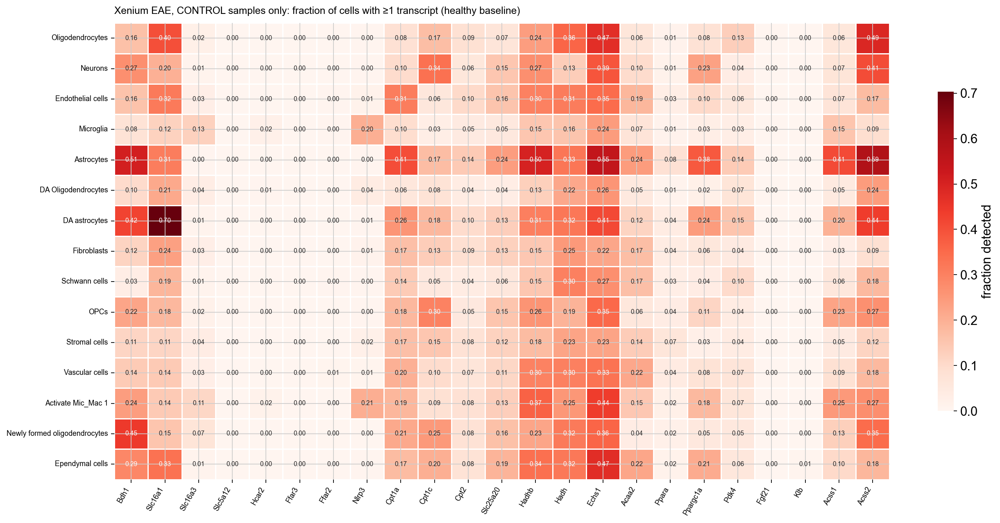

fatty-acid-supply score by cell type:


cell_type,Astrocytes,Foamy Mic_Mac,DA astrocytes,Mic_AST,Endothelial cells,Schwann cells,Activated Mic_Mac 2,Ependymal cells,Macrophages,Vascular cells,Fibroblasts,Proliferating microglia,T cells,DA Oligodendrocytes,Efflux Mic_Mac,Oligodendrocytes,Stromal cells,Newly formed oligodendrocytes,Microglia,Activate Mic_Mac 1,APCs,B cells,Dendritic cells,OPCs,Myeloid cells,Neurons
FA_supply_score,0.307,0.245,0.176,0.121,0.118,0.106,0.085,0.067,0.058,0.057,0.046,0.031,0.024,0.015,0.007,0.005,0.003,0.001,-0.016,-0.022,-0.024,-0.034,-0.056,-0.08,-0.082,-0.273


In [3]:
det = om.detection_table(ad, KG, "cell_type", min_cells=1500).loc[CTS]; save("detection_by_celltype", det)
heat(det[KG], "Xenium EAE: fraction of cells with ≥1 transcript (all samples)", "fraction detected", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(det.index))
mt = om.mean_table(ad, KG, "cell_type", min_cells=1500).loc[CTS]; save("mean_by_celltype", mt)
ctx = om.present(ad, ["C4b", "Plp1", "Aqp4", "Hexb", "Gfap", "Mbp"]); r = om.resolve(ad, KG + ctx)
sc.pl.dotplot(ad[ad.obs["cell_type"].isin(CTS)], var_names=[r[g] for g in KG + ctx], groupby="cell_type", standard_scale="var", color_map="Reds", figsize=(0.4 * (len(KG) + 4) + 2, 7), show=False, title="Xenium EAE: ketone-related genes by cell type"); plt.show()
# control tissue only: the healthy baseline
det_ctrl = om.detection_table(ad[ad.obs["condition"] == "CONTROL"], KG, "cell_type", min_cells=300); det_ctrl = det_ctrl.loc[[c for c in CTS if c in det_ctrl.index]]; save("detection_by_celltype_control_only", det_ctrl)
heat(det_ctrl[KG], "Xenium EAE, CONTROL samples only: fraction of cells with ≥1 transcript (healthy baseline)", "fraction detected", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(det_ctrl.index))
fa = ad.obs.groupby("cell_type")["FA_supply_score"].mean().loc[CTS].sort_values(ascending=False); save("FA_supply_score_by_celltype", fa.to_frame())
print("fatty-acid-supply score by cell type:"); display(fa.round(3).to_frame().T)

## 2. EAE vs control in every cell type; by model (RR / chronic) and by disease course

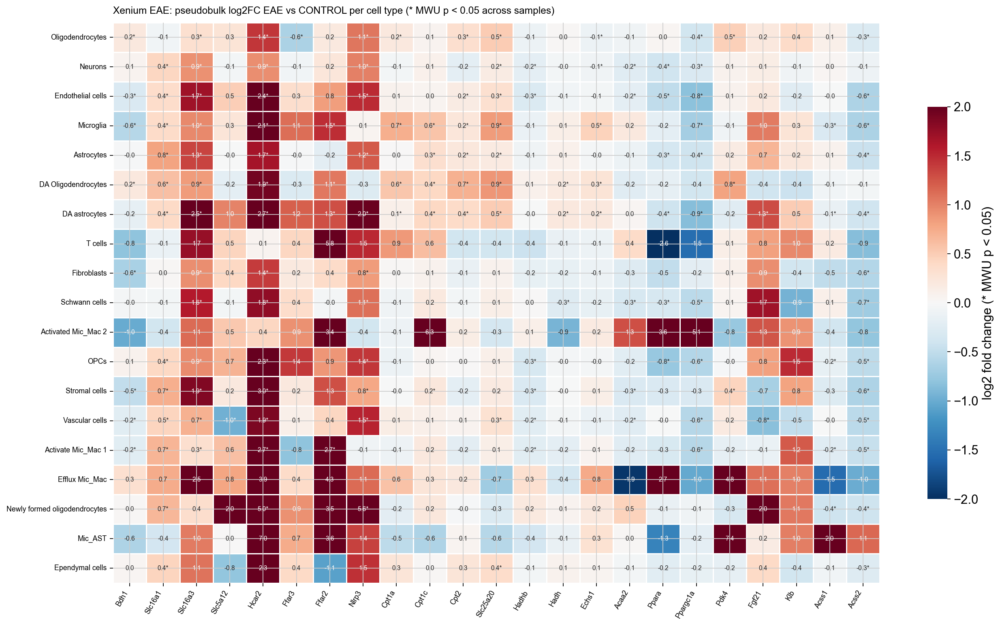

146 significant cell type × gene contrasts:


,cell_type,gene,group,mean_EAE,mean_CONTROL,log2FC,MWU_p,n_EAE,n_CONTROL
0,Schwann cells,Acaa2,Fatty-acid supply,0.388,0.491,-0.338,0.003,85,15
1,Stromal cells,Acaa2,Fatty-acid supply,0.269,0.333,-0.305,0.022,92,15
2,Neurons,Acaa2,Fatty-acid supply,0.162,0.193,-0.248,0.016,92,15
3,Vascular cells,Acaa2,Fatty-acid supply,0.448,0.530,-0.240,0.024,92,15
4,Endothelial cells,Acaa2,Fatty-acid supply,0.381,0.439,-0.202,0.034,92,15
5,Newly formed oligodendrocytes,Acss1,Acetate activation,0.219,0.292,-0.415,0.043,86,10
6,Microglia,Acss1,Acetate activation,0.316,0.390,-0.305,0.006,92,15
7,Activate Mic_Mac 1,Acss1,Acetate activation,0.465,0.551,-0.244,0.006,91,15
8,OPCs,Acss1,Acetate activation,0.467,0.524,-0.167,0.049,92,15
9,DA astrocytes,Acss1,Acetate activation,0.428,0.474,-0.146,0.032,92,15


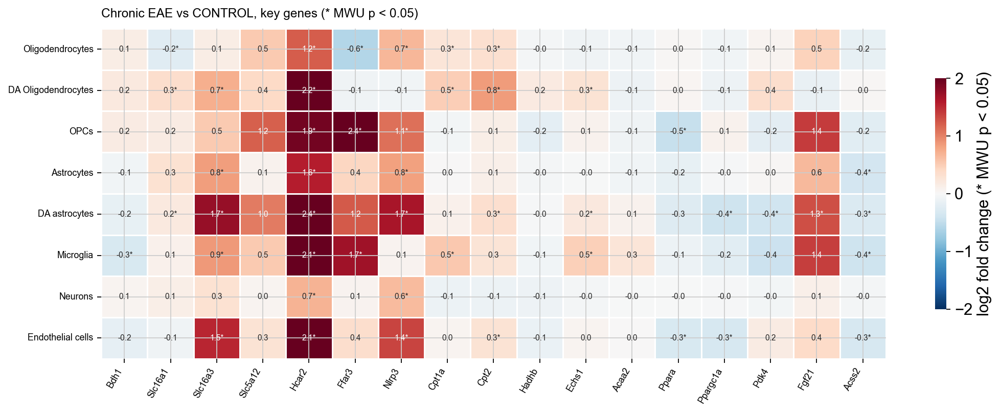

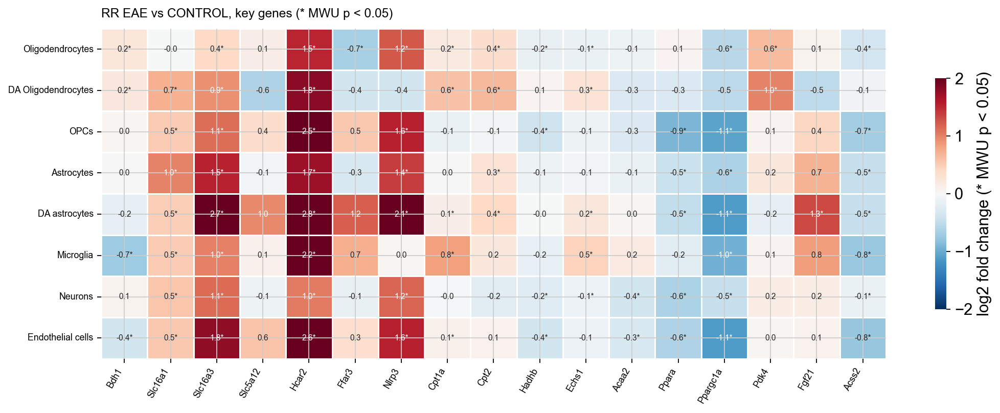

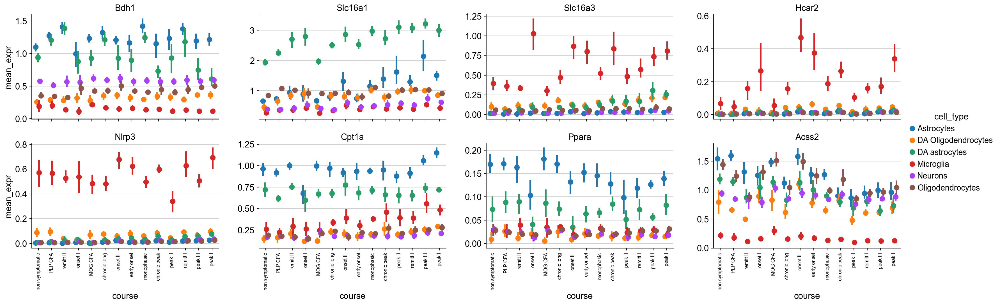

Bdh1  Slc16a1  Slc16a3  Slc5a12  Hcar2  Ffar3  Nlrp3  Cpt1a   Cpt2  Hadhb  Echs1  Acaa2  Ppara  Ppargc1a   Pdk4  Fgf21  Acss2
cell_type           course                                                                                                                                         
Astrocytes          MOG CFA          1.234    0.668    0.012    0.001  0.004  0.002  0.005  0.996  0.297  1.267  1.435  0.534  0.181     1.039  0.273  0.000  1.485
                    PLP CFA          1.278    0.730    0.007    0.000  0.001  0.000  0.007  0.920  0.297  1.192  1.316  0.535  0.171     0.751  0.297  0.000  1.598
                    chronic long     1.324    0.796    0.012    0.000  0.004  0.000  0.011  0.971  0.367  1.339  1.470  0.584  0.171     0.951  0.270  0.001  1.121
                    chronic peak     1.150    1.390    0.035    0.000  0.018  0.002  0.023  0.951  0.379  1.106  1.408  0.468  0.128     0.705  0.368  0.002  0.902
                    early onset      1.164    0.740    0.012    0.000  0.010  0.001  0.010  0.934  0.283  1.126  1.272  0.461  0.153     0.853  0.298  0.001  1.271
                    monophasic       1.421    1.147    0.022    0.000  0.005  0.001  0.014  0.938  0.340  1.226  1.411  0.533  0.145     0.607  0.276  0.001  1.269
                    non symptomatic  1.100    0.654    0.013    0.002  0.004  0.002  0.005  0.965  0.250  1.097  1.252  0.489  0.170     0.837  0.243  0.000  1.542
                    onset I          0.995    0.873    0.016    0.001  0.009  0.000  0.009  0.678  0.235  0.862  1.077  0.326  0.104     0.529  0.241  0.001  1.256
                    onset II         1.208    1.311    0.035    0.000  0.016  0.000  0.024  0.918  0.321  1.017  1.220  0.402  0.132     0.564  0.303  0.000  1.582
                    peak I           1.218    1.505    0.028    0.000  0.016  0.001  0.027  1.150  0.416  1.229  1.368  0.549  0.140     0.589  0.488  0.000  0.966
                    peak II          1.234    1.620    0.032    0.000  0.002  0.000  0.012  0.880  0.356  0.982  1.171  0.435  0.098     0.466  0.331  0.000  0.869
                    peak III         1.194    2.143    0.046    0.000  0.016  0.000  0.023  1.060  0.400  1.185  1.361  0.452  0.127     0.448  0.399  0.002  0.998
                    remitt I         1.378    1.298    0.025    0.000  0.005  0.000  0.020  0.914  0.369  1.276  1.343  0.552  0.119     0.600  0.297  0.001  0.945
                    remitt II        1.409    0.935    0.005    0.001  0.004  0.000  0.001  1.000  0.401  1.249  1.361  0.628  0.163     0.710  0.305  0.000  1.316
DA Oligodendrocytes MOG CFA          0.278    0.458    0.111    0.000  0.011  0.003  0.070  0.123  0.087  0.377  0.799  0.124  0.005     0.079  0.117  0.000  0.827
                    PLP CFA          0.288    0.651    0.071    0.002  0.008  0.000  0.095  0.162  0.096  0.331  0.705  0.135  0.027     0.061  0.208  0.002  0.659
                    chronic long     0.354    0.833    0.179    0.001  0.042  0.002  0.076  0.231  0.197  0.501  1.052  0.175  0.025     0.077  0.214  0.001  0.615
                    chronic peak     0.344    0.783    0.185    0.001  0.054  0.003  0.084  0.263  0.180  0.400  1.029  0.108  0.014     0.068  0.325  0.001  0.821
                    early onset      0.323    0.775    0.109    0.002  0.062  0.000  0.078  0.178  0.161  0.326  0.826  0.095  0.021     0.064  0.176  0.003  0.780
                    monophasic       0.295    1.016    0.155    0.000  0.033  0.000  0.060  0.200  0.134  0.357  0.899  0.101  0.016     0.048  0.271  0.001  0.650
                    non symptomatic  0.259    0.447    0.098    0.004  0.009  0.000  0.089  0.149  0.113  0.318  0.655  0.085  0.009     0.037  0.185  0.000  0.793
                    onset I          0.317    0.894    0.114    0.001  0.022  0.002  0.032  0.121  0.126  0.319  0.752  0.065  0.020     0.040  0.573  0.001  0.897
                    onset II         0.360    0.799    0.127    0.001  0.046  0.001  0.059  0.207  0.1

Spearman correlation across EAE samples between per-sample mean expression and the sample's lesion fraction:


cell_type,Astrocytes,DA Oligodendrocytes,DA astrocytes,Microglia,Oligodendrocytes
gene,,,,,
Acaa2,0.07,0.17,0.12,0.23,0.28
Acss2,-0.49,-0.13,-0.49,-0.41,-0.36
Bdh1,0.21,0.27,-0.25,-0.30,0.39
Cpt1a,0.23,0.42,0.08,0.60,0.47
Cpt2,0.46,0.08,0.26,0.29,0.09
Echs1,0.16,0.34,0.40,0.40,-0.00
Ffar3,-0.10,-0.01,-0.22,0.21,0.18
Fgf21,0.02,0.19,0.18,0.15,-0.18
Hadhb,0.11,0.16,0.03,0.20,0.00


In [4]:
de, pb = pseudobulk_test(ad, KG, "sample_name", "condition", "EAE", "CONTROL", cts=CTS); save("EAE_vs_control", de)
fc_heat(de, "Xenium EAE: pseudobulk log2FC EAE vs CONTROL per cell type (* MWU p < 0.05 across samples)", CTS, KG, "EAE", "CONTROL")
sig = de[(de.MWU_p < 0.05)].sort_values(["gene", "log2FC"]); print(f"{len(sig)} significant cell type × gene contrasts:"); display(sig.round(3).reset_index(drop=True))
# by model
for model in sorted(ad.obs["model"].astype(str).unique()):
    m = ad[(ad.obs["model"].astype(str) == model) | (ad.obs["condition"] == "CONTROL")]
    de_m, _ = pseudobulk_test(m, KEY, "sample_name", "condition", "EAE", "CONTROL", cts=["Oligodendrocytes", "DA Oligodendrocytes", "OPCs", "Astrocytes", "DA astrocytes", "Microglia", "Neurons", "Endothelial cells"])
    de_m["model"] = model; save(f"EAE_vs_control_model_{model}", de_m)
    fc_heat(de_m, f"{model} EAE vs CONTROL, key genes (* MWU p < 0.05)", ["Oligodendrocytes", "DA Oligodendrocytes", "OPCs", "Astrocytes", "DA astrocytes", "Microglia", "Neurons", "Endothelial cells"], KEY, "EAE", "CONTROL")
    del m
# by disease course: pseudobulk per sample for the main cell types, plotted along course labels
courses = [c for c in ad.obs["course"].astype(str).unique() if c not in ("nan", "None")]
pb_c = pb[pb.cell_type.isin(["Oligodendrocytes", "DA Oligodendrocytes", "Astrocytes", "DA astrocytes", "Microglia", "Neurons"])].merge(meta[["course", "model", "frac_lesion"]], left_on="sample_name", right_index=True, suffixes=("", "_meta"))
tidy = pb_c.melt(id_vars=["sample_name", "cell_type", "condition", "course", "model", "frac_lesion"], value_vars=KEY, var_name="gene", value_name="mean_expr")
order_c = list(meta.groupby("course", observed=True)["frac_lesion"].mean().sort_values().index)
g = sns.catplot(data=tidy[tidy.gene.isin(["Bdh1", "Slc16a1", "Slc16a3", "Hcar2", "Cpt1a", "Ppara", "Acss2", "Nlrp3"])], x="course", y="mean_expr", hue="cell_type", col="gene", col_wrap=4, kind="point", order=order_c, dodge=0.4, errorbar=("ci", 95), linestyle="none", height=3.2, aspect=1.6, sharey=False)
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
g.set_titles("{col_name}"); plt.show()
course_tab = pb_c.groupby(["cell_type", "course"], observed=True)[KEY].mean().round(3); save("pseudobulk_by_course", course_tab); display(course_tab)
# sample-level: does Bdh1 / Slc16a1 in oligodendrocytes track lesion burden?
rows = []
for ct in ["Oligodendrocytes", "DA Oligodendrocytes", "Astrocytes", "DA astrocytes", "Microglia"]:
    p_ct = pb_c[(pb_c.cell_type == ct) & (pb_c.condition == "EAE")]
    for gname in KEY:
        if p_ct[gname].std() > 0:
            rho, p = stats.spearmanr(p_ct["frac_lesion"], p_ct[gname]); rows.append({"cell_type": ct, "gene": gname, "n_samples": len(p_ct), "spearman_rho_vs_lesion_fraction": rho, "p": p})
burden = pd.DataFrame(rows); save("gene_vs_lesion_burden_across_samples", burden)
print("Spearman correlation across EAE samples between per-sample mean expression and the sample's lesion fraction:"); display(burden.pivot(index="gene", columns="cell_type", values="spearman_rho_vs_lesion_fraction").round(2))

## 3. Lesion distance, per cell type

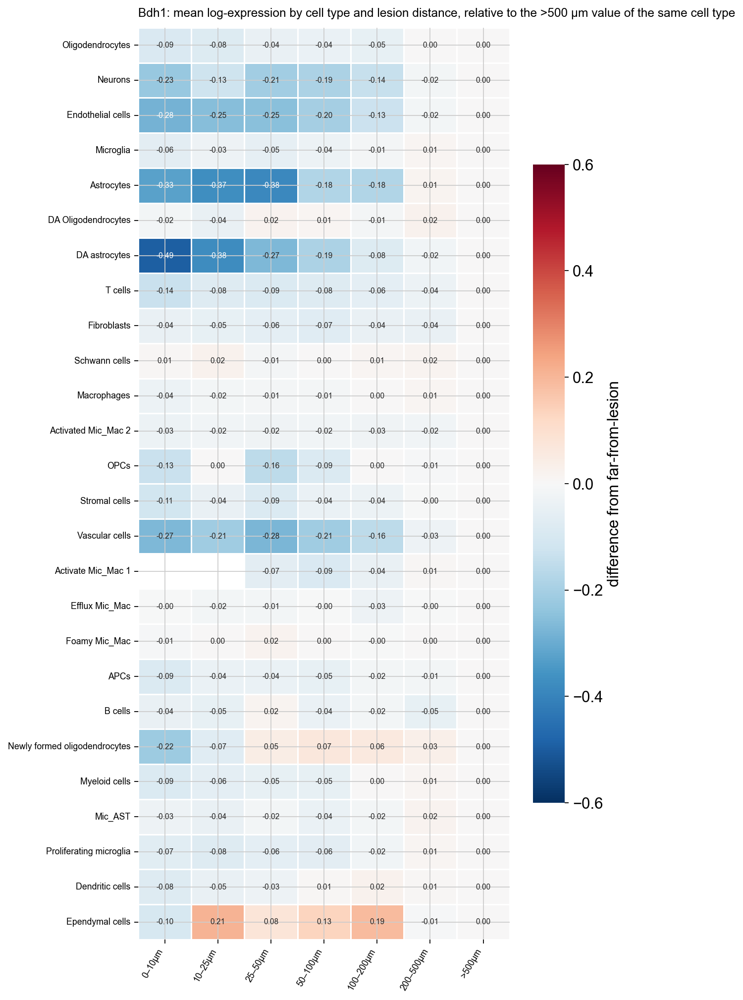

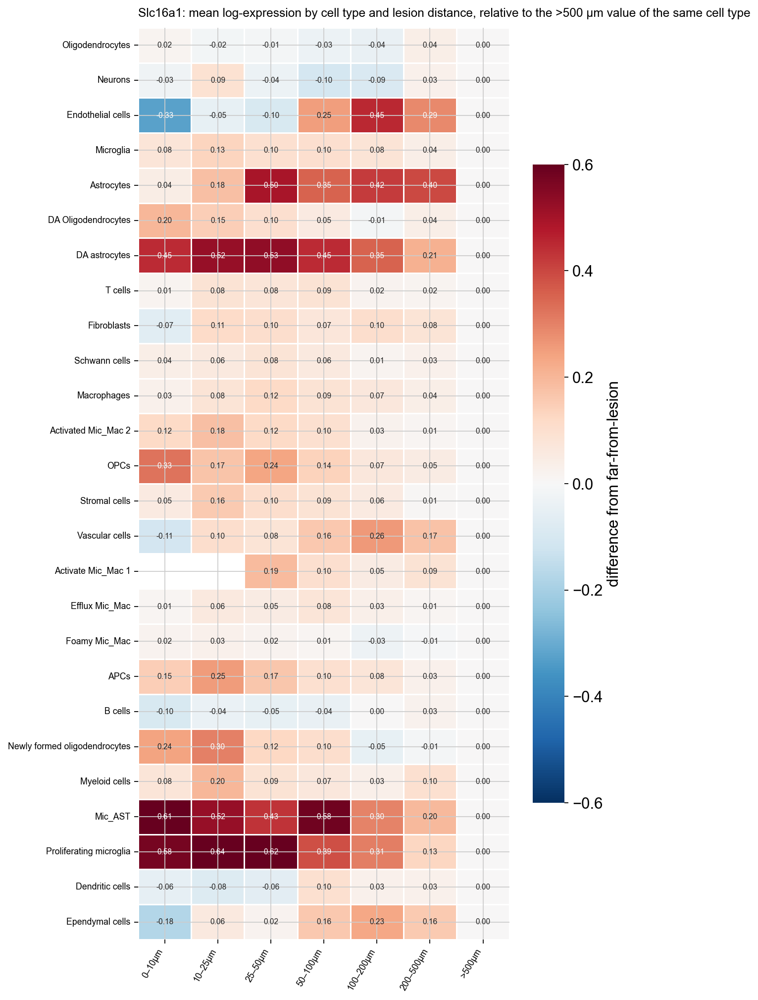

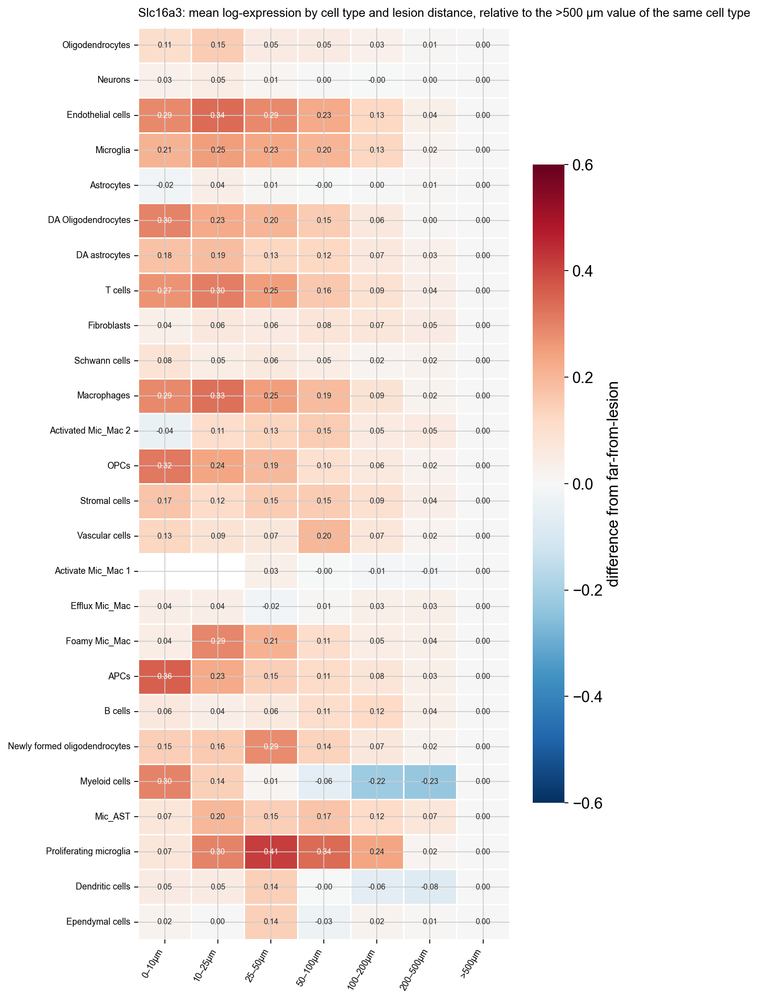

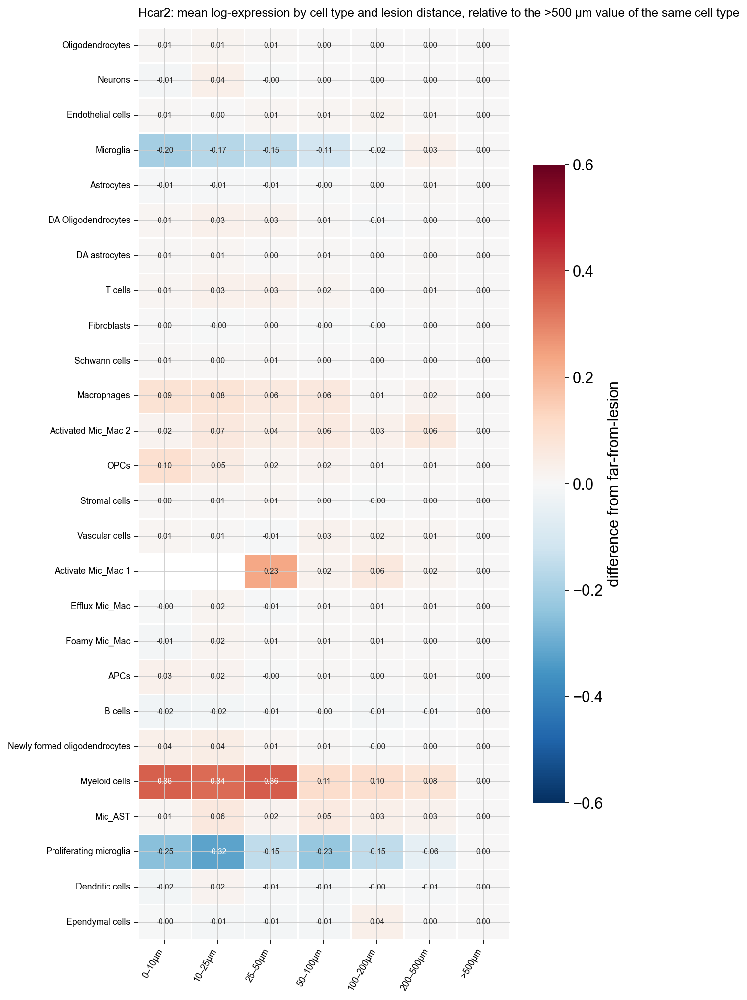

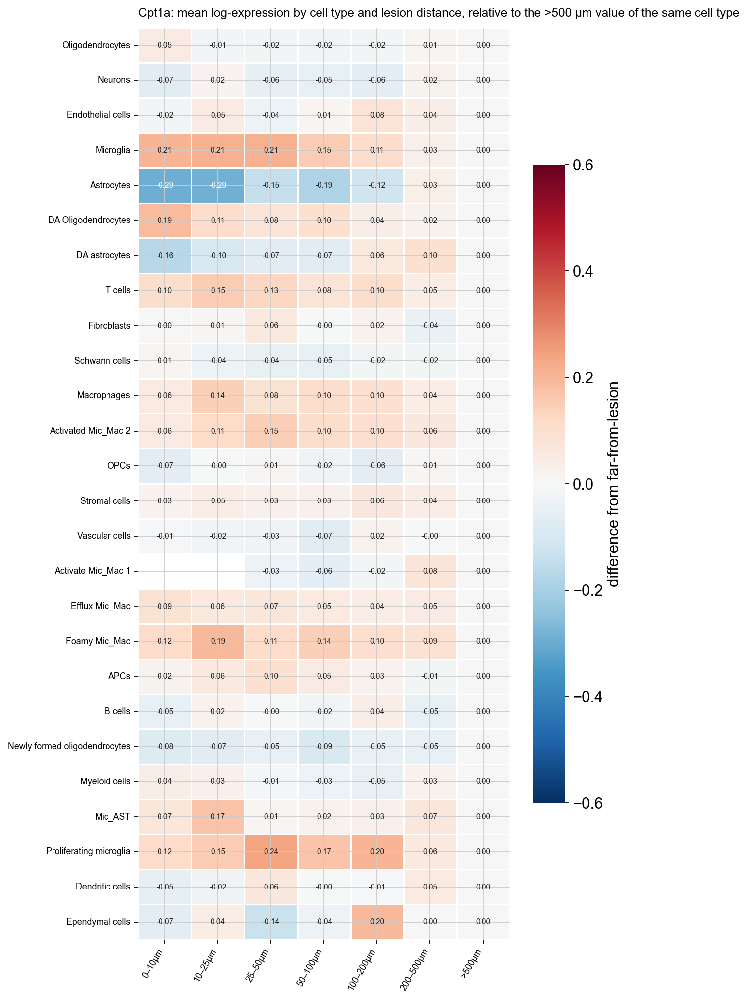

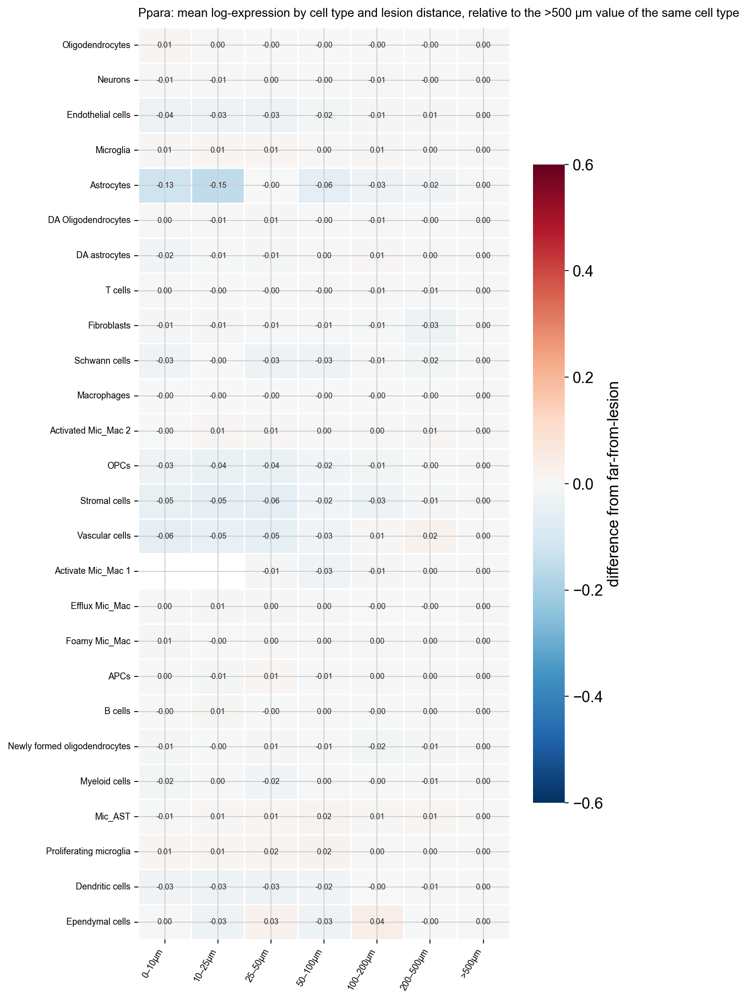

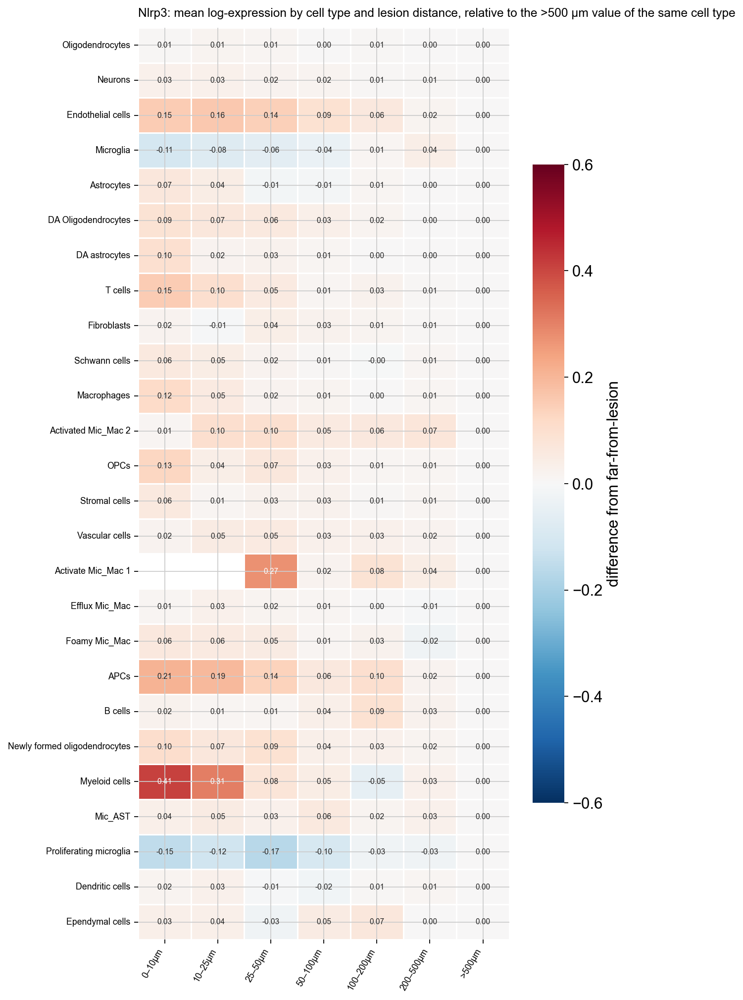

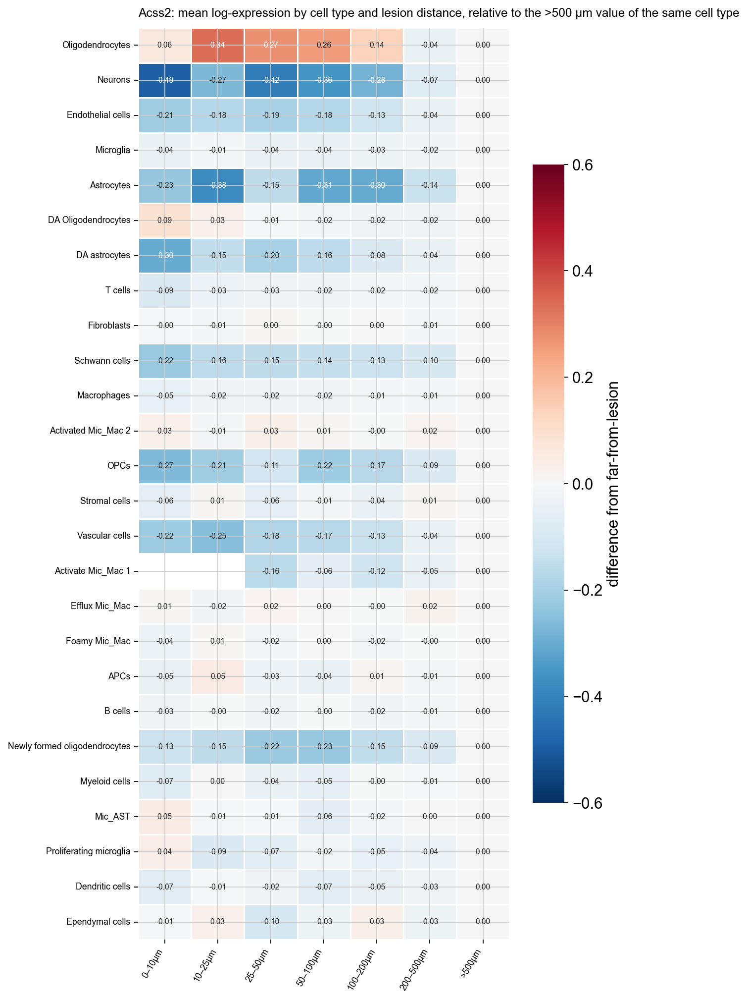

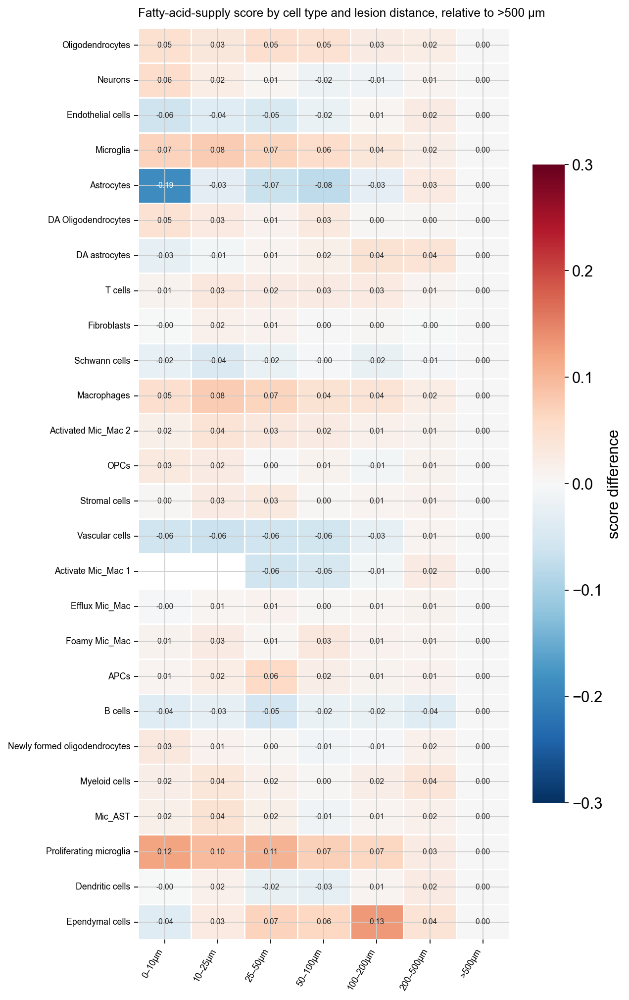

In [5]:
m_eae = ((ad.obs["condition"] == "EAE") & ad.obs["lesion_distance_bin"].notna()).values
bins = bin_order(ad.obs.loc[m_eae, "lesion_distance_bin"].astype(str).unique())
s_all = ad[m_eae]
df = om.expr_df(s_all, KEY); ct_bin = df.groupby([s_all.obs["cell_type"].astype(str).values, s_all.obs["lesion_distance_bin"].astype(str).values]).mean()
n_ct_bin = s_all.obs.groupby([s_all.obs["cell_type"].astype(str).values, s_all.obs["lesion_distance_bin"].astype(str).values]).size(); ct_bin = ct_bin[n_ct_bin >= 50]
ct_bin.index.names = ["cell_type", "bin"]; save("lesion_distance_by_celltype", ct_bin)
for gname in ["Bdh1", "Slc16a1", "Slc16a3", "Hcar2", "Cpt1a", "Ppara", "Nlrp3", "Acss2"]:
    m = ct_bin[gname].unstack("bin").reindex(columns=bins); m = m.loc[[c for c in CTS if c in m.index]]
    far = m[bins[-1]]
    heat(m.sub(far, axis=0), f"{gname}: mean log-expression by cell type and lesion distance, relative to the >500 µm value of the same cell type", "difference from far-from-lesion", fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6, row_labels=list(m.index))
fa_bin = s_all.obs.groupby([s_all.obs["cell_type"].astype(str).values, s_all.obs["lesion_distance_bin"].astype(str).values])["FA_supply_score"].mean(); fa_bin = fa_bin[n_ct_bin >= 50].unstack(1).reindex(columns=bins).loc[[c for c in CTS if c in fa_bin.index.get_level_values(0)]]
save("FA_supply_score_lesion_distance", fa_bin)
heat(fa_bin.sub(fa_bin[bins[-1]], axis=0), "Fatty-acid-supply score by cell type and lesion distance, relative to >500 µm", "score difference", fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3, row_labels=list(fa_bin.index))
del s_all, df

## 4. The disease-associated oligodendrocyte and astrocyte states (paired within sample)

=== DA_vs_homeostatic_oligodendrocytes


,group,mean_DA,mean_homeo,log2FC,n_samples,frac_samples_up,wilcoxon_p
gene,,,,,,,
Bdh1,Ketone enzyme on the panel,0.3211,0.4300,-0.4200,107,0.0374,0.0000
Slc16a1,Transport,0.8302,0.9591,-0.2081,107,0.2523,0.0000
Slc16a3,Transport,0.1486,0.0628,1.2301,107,0.9533,0.0000
Slc5a12,Transport,0.0010,0.0010,-0.0414,107,0.1308,0.1204
Hcar2,Sensing,0.0329,0.0072,2.0577,107,0.8598,0.0000
Ffar3,Sensing,0.0009,0.0011,-0.1286,107,0.1589,0.0431
Ffar2,Sensing,0.0075,0.0041,0.7503,107,0.5421,0.0010
Nlrp3,Sensing,0.0722,0.0137,2.3157,107,0.9907,0.0000
Cpt1a,Fatty-acid supply,0.2058,0.2189,-0.0888,107,0.3645,0.0055


=== C4bhigh_vs_C4bneg_oligodendrocytes


,group,mean_C4b_high,mean_C4b_neg,log2FC,n_samples,frac_samples_up,wilcoxon_p
gene,,,,,,,
Bdh1,Ketone enzyme on the panel,0.2951,0.3522,-0.2544,100,0.32,0.0000
Slc16a1,Transport,0.8683,0.7301,0.2498,100,0.70,0.0000
Slc16a3,Transport,0.0861,0.0738,0.2205,100,0.59,0.0141
Slc5a12,Transport,0.0010,0.0005,0.3831,100,0.10,0.1790
Hcar2,Sensing,0.0084,0.0078,0.0953,100,0.39,0.9139
Ffar3,Sensing,0.0007,0.0009,-0.1654,100,0.09,0.7570
Ffar2,Sensing,0.0041,0.0074,-0.7165,100,0.29,0.1712
Nlrp3,Sensing,0.0209,0.0191,0.1258,100,0.53,0.0716
Cpt1a,Fatty-acid supply,0.1638,0.1893,-0.2073,100,0.38,0.0040


=== DA_vs_homeostatic_astrocytes


,group,mean_DA,mean_homeo,log2FC,n_samples,frac_samples_up,wilcoxon_p
gene,,,,,,,
Bdh1,Ketone enzyme on the panel,0.9856,1.2455,-0.3373,107,0.1308,0.0000
Slc16a1,Transport,2.7254,1.1596,1.2321,107,1.0000,0.0000
Slc16a3,Transport,0.1315,0.0221,2.5164,107,0.9346,0.0000
Slc5a12,Transport,0.0008,0.0003,0.4707,107,0.1121,0.0735
Hcar2,Sensing,0.0146,0.0081,0.7791,107,0.6449,0.0000
Ffar3,Sensing,0.0011,0.0006,0.3967,107,0.1776,0.0859
Ffar2,Sensing,0.0065,0.0024,1.1612,107,0.5888,0.0000
Nlrp3,Sensing,0.0379,0.0143,1.3438,107,0.8692,0.0000
Cpt1a,Fatty-acid supply,0.6870,0.9548,-0.4741,107,0.0374,0.0000


=== NFOL_vs_homeostatic_oligodendrocytes


,group,mean_NFOL,mean_homeo,log2FC,n_samples,frac_samples_up,wilcoxon_p
gene,,,,,,,
Bdh1,Ketone enzyme on the panel,1.1423,0.4341,1.3938,96,1.0000,0.0000
Slc16a1,Transport,0.4697,0.9689,-1.0432,96,0.0000,0.0000
Slc16a3,Transport,0.2234,0.0636,1.7956,96,0.9167,0.0000
Slc5a12,Transport,0.0027,0.0009,0.9185,96,0.0417,0.0006
Hcar2,Sensing,0.0268,0.0072,1.7547,96,0.5208,0.0001
Ffar3,Sensing,0.0008,0.0010,-0.1552,96,0.0729,0.0020
Ffar2,Sensing,0.0091,0.0042,0.9549,96,0.2604,0.1516
Nlrp3,Sensing,0.0439,0.0141,1.5672,96,0.6146,0.0000
Cpt1a,Fatty-acid supply,0.4105,0.2214,0.8876,96,0.9167,0.0000


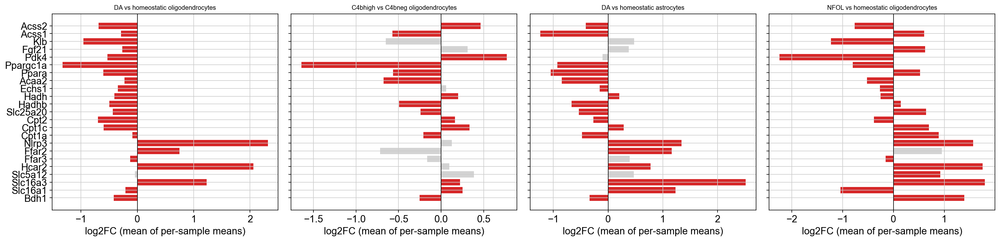

In [6]:
ct_ = ad.obs["cell_type"].values
c4b = om.expr(ad, "C4b"); is_ol = np.isin(ct_, ["Oligodendrocytes", "DA Oligodendrocytes"]); thr = np.quantile(c4b[is_ol & (c4b > 0)], 0.75)
tests = {"DA_vs_homeostatic_oligodendrocytes": (ct_ == "DA Oligodendrocytes", ct_ == "Oligodendrocytes", "DA", "homeo"),
         "C4bhigh_vs_C4bneg_oligodendrocytes": (is_ol & (c4b >= thr), is_ol & (c4b == 0), "C4b_high", "C4b_neg"),
         "DA_vs_homeostatic_astrocytes": (ct_ == "DA astrocytes", ct_ == "Astrocytes", "DA", "homeo"),
         "NFOL_vs_homeostatic_oligodendrocytes": (ct_ == "Newly formed oligodendrocytes", ct_ == "Oligodendrocytes", "NFOL", "homeo")}
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (name, (ma, mb, la, lb)) in zip(axes, tests.items()):
    t = paired_genes(ad, KG, "sample_name", ma, mb, la, lb); save(name, t)
    print(f"=== {name}"); display(t.round(4))
    cols = ["tab:red" if (p < 0.05) else "lightgrey" for p in t["wilcoxon_p"]]
    ax.barh(t.index, t["log2FC"], color=cols); ax.axvline(0, c="k", lw=0.8); ax.set_title(name.replace("_", " "), fontsize=9); ax.set_xlabel("log2FC (mean of per-sample means)")
plt.tight_layout(); plt.show()

## 5. What does *Bdh1* keep company with? (direction of the reaction)

*Bdh1* is bidirectional. If *Bdh1*⁺ cells of a type are enriched for the β-oxidation chain (*Cpt1a*, *Hadhb*, *Echs1*, *Acaa2*) and *Ppara*, the cell is set
up to *make* BHB from fatty acids; if they are enriched for MCT1 and the acetate / glycolytic side, the picture is export or consumption. Tested inside
astrocytes, oligodendrocytes, OPCs, microglia and neurons, in control and EAE separately.

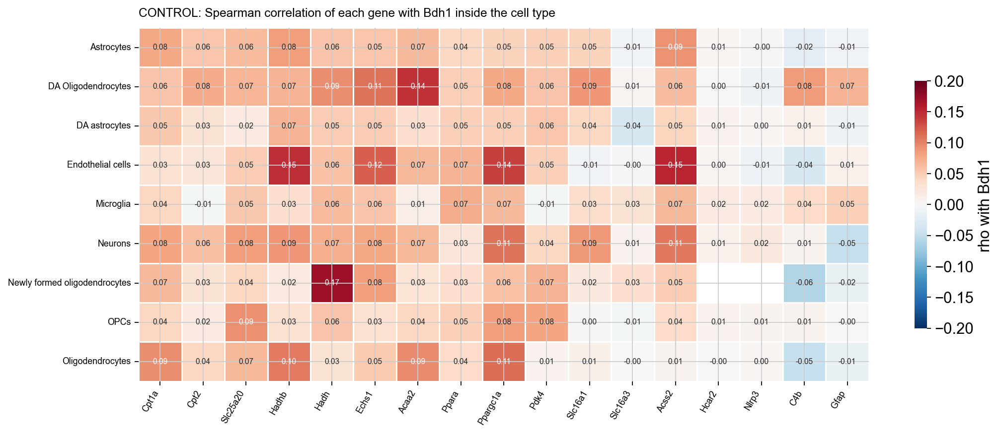

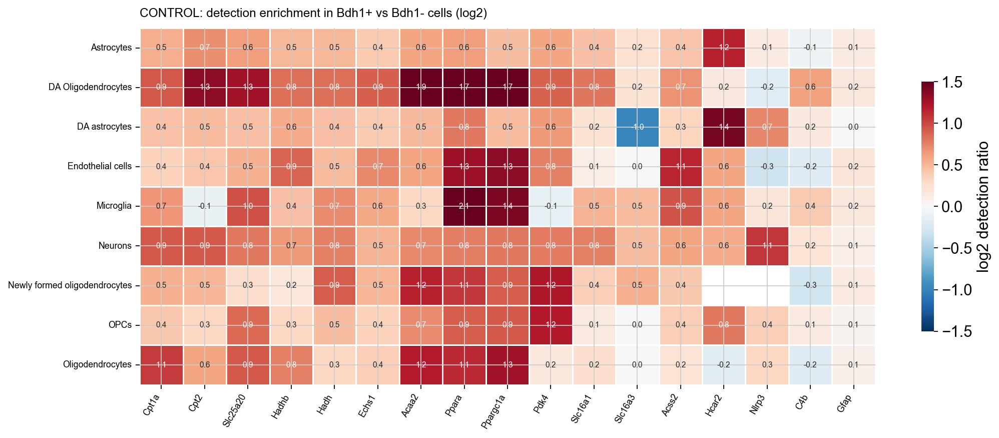

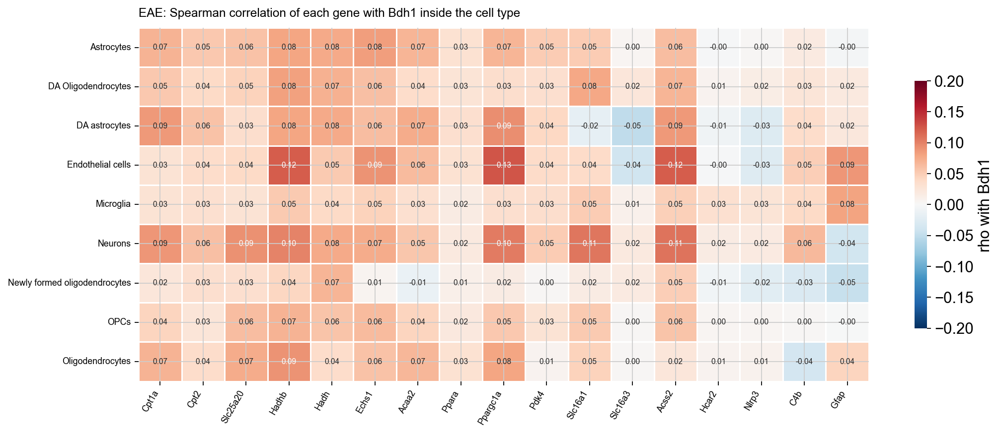

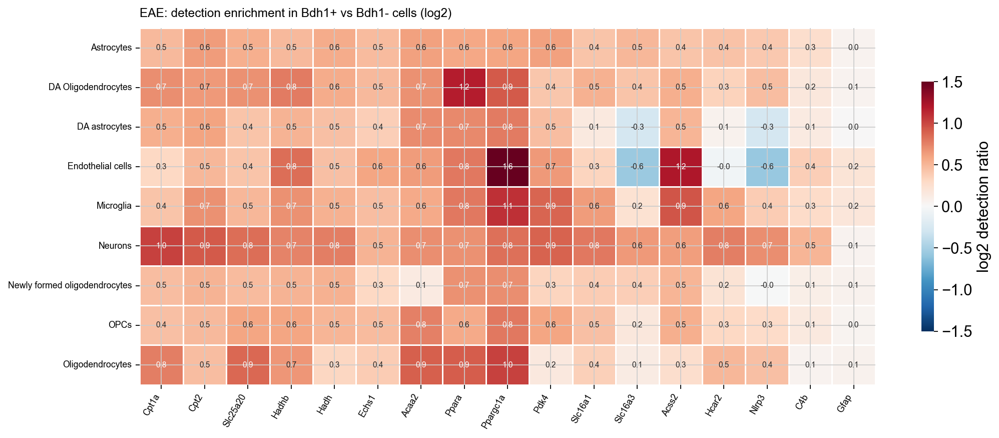

,FA_supply_score_Bdh1+,FA_supply_score_Bdh1-,n_Bdh1+,diff
cell_type,,,,
Astrocytes,0.360,0.252,26072,0.108
DA astrocytes,0.225,0.141,15038,0.084
Oligodendrocytes,0.044,-0.004,26733,0.048
DA Oligodendrocytes,0.043,0.011,6371,0.032
OPCs,-0.070,-0.083,5265,0.013
Microglia,0.005,-0.017,3303,0.022
Neurons,-0.265,-0.276,39914,0.011


In [7]:
partners = [g for g in ["Cpt1a", "Cpt2", "Slc25a20", "Hadhb", "Hadh", "Echs1", "Acaa2", "Ppara", "Ppargc1a", "Pdk4", "Slc16a1", "Slc16a3", "Acss2", "Hcar2", "Nlrp3", "C4b", "Gfap", "Plp1"] if g in ad.var_names]
rows = []
for ct in ["Astrocytes", "DA astrocytes", "Oligodendrocytes", "DA Oligodendrocytes", "Newly formed oligodendrocytes", "OPCs", "Microglia", "Neurons", "Endothelial cells"]:
    for cond in ["CONTROL", "EAE"]:
        sub = ad[(ad.obs["cell_type"] == ct) & (ad.obs["condition"] == cond)]
        if sub.n_obs < 300 or (om.expr(sub, "Bdh1") > 0).sum() < 50:
            continue
        co = om.coexpression_with_anchor(sub, "Bdh1", partners, min_pos=50); co["cell_type"] = ct; co["condition"] = cond; co["n_cells"] = sub.n_obs
        rows.append(co.reset_index()); del sub
BDH = pd.concat(rows, ignore_index=True); save("Bdh1_company", BDH)
for cond in ["CONTROL", "EAE"]:
    piv = BDH[BDH.condition == cond].pivot(index="cell_type", columns="gene", values="spearman_rho")[partners]
    heat(piv, f"{cond}: Spearman correlation of each gene with Bdh1 inside the cell type", "rho with Bdh1", fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2, row_labels=list(piv.index))
    piv2 = BDH[BDH.condition == cond].pivot(index="cell_type", columns="gene", values="enrichment(+/-)")[partners]
    heat(np.log2(piv2.replace(0, np.nan)), f"{cond}: detection enrichment in Bdh1+ vs Bdh1- cells (log2)", "log2 detection ratio", fmt=".1f", cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5, row_labels=list(piv2.index))
fa_by_bdh = []
for ct in ["Astrocytes", "DA astrocytes", "Oligodendrocytes", "DA Oligodendrocytes", "OPCs", "Microglia", "Neurons"]:
    m = (ad.obs["cell_type"] == ct).values; b = om.expr(ad, "Bdh1") > 0
    fa_by_bdh.append({"cell_type": ct, "FA_supply_score_Bdh1+": ad.obs.loc[m & b, "FA_supply_score"].mean(), "FA_supply_score_Bdh1-": ad.obs.loc[m & ~b, "FA_supply_score"].mean(), "n_Bdh1+": int((m & b).sum())})
fa_by_bdh = pd.DataFrame(fa_by_bdh).set_index("cell_type"); fa_by_bdh["diff"] = fa_by_bdh.iloc[:, 0] - fa_by_bdh.iloc[:, 1]; save("FA_supply_score_by_Bdh1", fa_by_bdh); display(fa_by_bdh.round(3))

## 6. Myeloid ketone sensing: *Hcar2* and *Nlrp3*

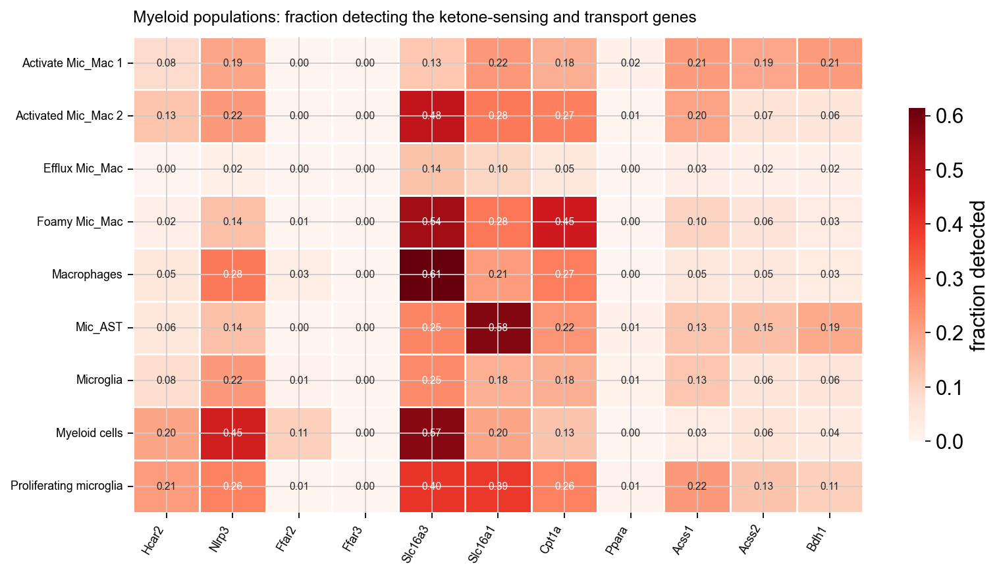

,n,Hcar2+,Nlrp3+,both,both_expected
cell_type,,,,,
Activate Mic_Mac 1,18077,0.084,0.194,0.026,0.016
Activated Mic_Mac 2,24097,0.132,0.217,0.046,0.029
Efflux Mic_Mac,17895,0.003,0.021,0.000,0.000
Foamy Mic_Mac,12961,0.022,0.143,0.004,0.003
Macrophages,32806,0.054,0.280,0.022,0.015
Mic_AST,8134,0.055,0.142,0.011,0.008
Microglia,56065,0.083,0.217,0.030,0.018
Myeloid cells,10389,0.199,0.446,0.114,0.089
Proliferating microglia,7082,0.212,0.259,0.086,0.055


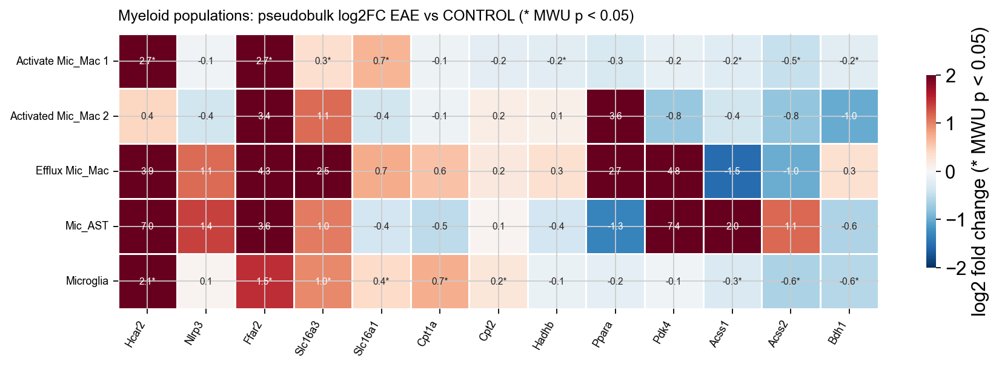

all myeloid cells in EAE: mean log-expression by lesion distance


,Hcar2,Nlrp3,Slc16a3,Cpt1a,Ppara
0–10µm,0.173,0.637,1.330,0.565,0.013
10–25µm,0.199,0.601,1.355,0.613,0.017
25–50µm,0.187,0.546,1.266,0.595,0.015
50–100µm,0.184,0.531,1.219,0.584,0.015
100–200µm,0.195,0.527,1.088,0.563,0.015
200–500µm,0.225,0.527,0.885,0.504,0.019
>500µm,0.213,0.499,0.798,0.433,0.019


inside myeloid cells: genes vs Hcar2


,frac_in_Hcar2-,frac_in_Hcar2+,enrichment(+/-),spearman_rho,fisher_p
gene,,,,,
Nlrp3,0.1980,0.3814,1.9268,0.1177,0.0
Slc16a3,0.3529,0.4923,1.3951,0.0665,0.0
Cpt1a,0.2138,0.2363,1.1049,0.0035,0.0
Ppara,0.0082,0.0081,0.9939,-0.0011,1.0
Pdk4,0.0300,0.0386,1.2851,0.0119,0.0
Bdh1,0.0680,0.0920,1.3531,0.0219,0.0
Acss2,0.0715,0.0999,1.3985,0.0258,0.0
Cd36,0.1173,0.2805,2.3908,0.1271,0.0
Lpl,0.1956,0.2698,1.3793,0.0450,0.0


In [8]:
my = ad[ad.obs["cell_type"].isin(MYELOID)].copy()
d = om.detection_table(my, ["Hcar2", "Nlrp3", "Ffar2", "Ffar3", "Slc16a3", "Slc16a1", "Cpt1a", "Ppara", "Acss1", "Acss2", "Bdh1"], "cell_type", min_cells=300); save("myeloid_detection", d)
heat(d.drop(columns="n_cells"), "Myeloid populations: fraction detecting the ketone-sensing and transport genes", "fraction detected", fmt=".2f", cmap="Reds", center=None, vmin=0, vmax=None, row_labels=list(d.index))
cd = pd.DataFrame([{"cell_type": ct, "n": int((my.obs["cell_type"] == ct).sum()), "Hcar2+": (om.expr(my, "Hcar2")[(my.obs["cell_type"] == ct).values] > 0).mean(),
                    "Nlrp3+": (om.expr(my, "Nlrp3")[(my.obs["cell_type"] == ct).values] > 0).mean(),
                    "both": ((om.expr(my, "Hcar2") > 0) & (om.expr(my, "Nlrp3") > 0))[(my.obs["cell_type"] == ct).values].mean()} for ct in d.index]).set_index("cell_type")
cd["both_expected"] = cd["Hcar2+"] * cd["Nlrp3+"]; save("myeloid_Hcar2_Nlrp3_codetection", cd); display(cd.round(3))
de_my, pb_my = pseudobulk_test(my, ["Hcar2", "Nlrp3", "Ffar2", "Slc16a3", "Slc16a1", "Cpt1a", "Cpt2", "Hadhb", "Ppara", "Pdk4", "Acss1", "Acss2", "Bdh1"], "sample_name", "condition", "EAE", "CONTROL", cts=list(d.index)); save("myeloid_EAE_vs_control", de_my)
fc_heat(de_my, "Myeloid populations: pseudobulk log2FC EAE vs CONTROL (* MWU p < 0.05)", list(d.index), ["Hcar2", "Nlrp3", "Ffar2", "Slc16a3", "Slc16a1", "Cpt1a", "Cpt2", "Hadhb", "Ppara", "Pdk4", "Acss1", "Acss2", "Bdh1"], "EAE", "CONTROL")
m_e = ((my.obs["condition"] == "EAE") & my.obs["lesion_distance_bin"].notna()).values
ld = om.mean_table(my[m_e], ["Hcar2", "Nlrp3", "Slc16a3", "Cpt1a", "Ppara"], "lesion_distance_bin", min_cells=100).reindex(bins); save("myeloid_lesion_distance", ld)
print("all myeloid cells in EAE: mean log-expression by lesion distance"); display(ld.round(3))
hc = om.coexpression_with_anchor(my, "Hcar2", ["Nlrp3", "Slc16a3", "Cpt1a", "Ppara", "Pdk4", "Bdh1", "Acss2", "Cd36", "Lpl", "Plin2", "C4b"], min_pos=50); save("myeloid_Hcar2_company", hc)
print("inside myeloid cells: genes vs Hcar2"); display(hc[["frac_in_Hcar2-", "frac_in_Hcar2+", "enrichment(+/-)", "spearman_rho", "fisher_p"]].round(4))
del my

## 7. Spatial neighbourhoods

Are ketogenic-competent astrocytes (*Bdh1*⁺, *Cpt1a*⁺, *Bdh1*⁺*Cpt1a*⁺), MCT4⁺ astrocytes, *Hcar2*⁺ and *Nlrp3*⁺ myeloid cells enriched within 30 µm of
(a) DA versus homeostatic oligodendrocytes and (b) *C4b*-high versus *C4b*-negative oligodendrocytes, in EAE samples, with the lesion-distance-matched control.

,source,target,n_samples,median_ratio,frac_samples_gt1,wilcoxon_p,lesion_matched_n,lesion_matched_median_ratio,lesion_matched_wilcoxon_p
0,DA vs homeostatic oligodendrocytes,Bdh1+ astrocytes,92,0.8228,0.1739,0.0000,77,0.8701,0.0000
1,DA vs homeostatic oligodendrocytes,Cpt1a+ astrocytes,92,0.7707,0.0870,0.0000,77,0.8965,0.0000
2,DA vs homeostatic oligodendrocytes,Bdh1+Cpt1a+ astrocytes,92,0.6852,0.0978,0.0000,77,0.8175,0.0000
3,DA vs homeostatic oligodendrocytes,Slc16a3+ astrocytes,75,1.9481,0.8933,0.0000,70,1.4940,0.0000
4,DA vs homeostatic oligodendrocytes,Hcar2+ myeloid,88,1.6193,0.9205,0.0000,77,1.2367,0.0000
5,DA vs homeostatic oligodendrocytes,Nlrp3+ myeloid,92,1.6362,0.9348,0.0000,77,1.3419,0.0000
6,DA vs homeostatic oligodendrocytes,Slc16a1+ endothelial,92,0.7726,0.0978,0.0000,77,0.8756,0.0000
7,C4b-high vs C4b-neg oligodendrocytes,Bdh1+ astrocytes,87,1.0349,0.5402,0.4262,76,1.0373,0.3434
8,C4b-high vs C4b-neg oligodendrocytes,Cpt1a+ astrocytes,87,0.9001,0.3793,0.0563,76,1.0594,0.5175
9,C4b-high vs C4b-neg oligodendrocytes,Bdh1+Cpt1a+ astrocytes,87,0.9331,0.4598,0.1276,76,1.0497,0.3514


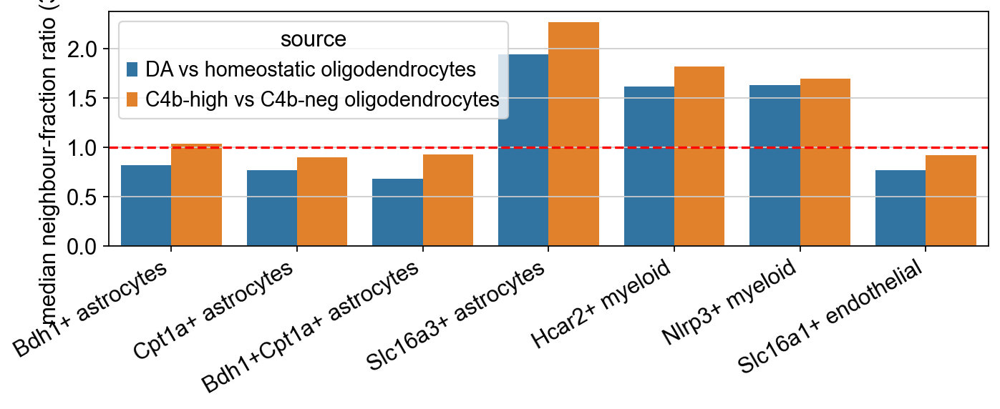

In [9]:
eae = ad[ad.obs["condition"] == "EAE"].copy()
ct_e = eae.obs["cell_type"].values; c4b_e = om.expr(eae, "C4b"); is_ol_e = np.isin(ct_e, ["Oligodendrocytes", "DA Oligodendrocytes"]); thr_e = np.quantile(c4b_e[is_ol_e & (c4b_e > 0)], 0.75)
sources = {"DA vs homeostatic oligodendrocytes": (ct_e == "DA Oligodendrocytes", ct_e == "Oligodendrocytes"),
           "C4b-high vs C4b-neg oligodendrocytes": (is_ol_e & (c4b_e >= thr_e), is_ol_e & (c4b_e == 0))}
astro_m = np.isin(ct_e, ASTRO); my_m = np.isin(ct_e, MYELOID)
targets = {"Bdh1+ astrocytes": (om.expr(eae, "Bdh1") > 0) & astro_m, "Cpt1a+ astrocytes": (om.expr(eae, "Cpt1a") > 0) & astro_m,
           "Bdh1+Cpt1a+ astrocytes": (om.expr(eae, "Bdh1") > 0) & (om.expr(eae, "Cpt1a") > 0) & astro_m, "Slc16a3+ astrocytes": (om.expr(eae, "Slc16a3") > 0) & astro_m,
           "Hcar2+ myeloid": (om.expr(eae, "Hcar2") > 0) & my_m, "Nlrp3+ myeloid": (om.expr(eae, "Nlrp3") > 0) & my_m, "Slc16a1+ endothelial": (om.expr(eae, "Slc16a1") > 0) & (ct_e == "Endothelial cells")}
strata = eae.obs["lesion_distance_bin"].astype(str).values
rows = []
for sname, (sa, sb) in sources.items():
    for tname, tgt in targets.items():
        j = om.compare_neighbourhoods(eae, "sample_name", sa, sb, tgt, "A", "B", radius=30.0, verbose=False)
        # lesion-distance-matched: per bin, per sample; median over bins within sample
        ratios = []
        for b in bins:
            m = strata == b
            A = om.neighbourhood_fraction(eae, "sample_name", sa & m, tgt, 30.0, min_source=20); B = om.neighbourhood_fraction(eae, "sample_name", sb & m, tgt, 30.0, min_source=20)
            jj = A[["frac_target_neighbours"]].join(B[["frac_target_neighbours"]], lsuffix="_A", rsuffix="_B", how="inner"); jj = jj[jj.iloc[:, 1] > 0]
            ratios += [(smp, r_ / rb) for smp, (r_, rb) in zip(jj.index, jj.values)]
        ps = pd.DataFrame(ratios, columns=["sample", "ratio"]).groupby("sample")["ratio"].median() if ratios else pd.Series(dtype=float)
        rows.append({"source": sname, "target": tname, "n_samples": len(j), "median_ratio": j["ratio"].median(), "frac_samples_gt1": (j["ratio"] > 1).mean(),
                     "wilcoxon_p": stats.wilcoxon(j.iloc[:, 0], j.iloc[:, 1]).pvalue if len(j) >= 3 else np.nan,
                     "lesion_matched_n": len(ps), "lesion_matched_median_ratio": ps.median() if len(ps) else np.nan,
                     "lesion_matched_wilcoxon_p": stats.wilcoxon(np.log(ps.clip(lower=1e-3))).pvalue if len(ps) >= 3 else np.nan})
NB = pd.DataFrame(rows); save("neighbourhoods", NB); display(NB.round(4))
plt.figure(figsize=(9, 3.8)); sns.barplot(data=NB, x="target", y="median_ratio", hue="source"); plt.axhline(1, ls="--", c="r"); plt.xticks(rotation=30, ha="right"); plt.ylabel("median neighbour-fraction ratio (30 µm)"); plt.xlabel(""); plt.tight_layout(); plt.show()
del eae

## 8. Maps (one peak-EAE and one control sample)

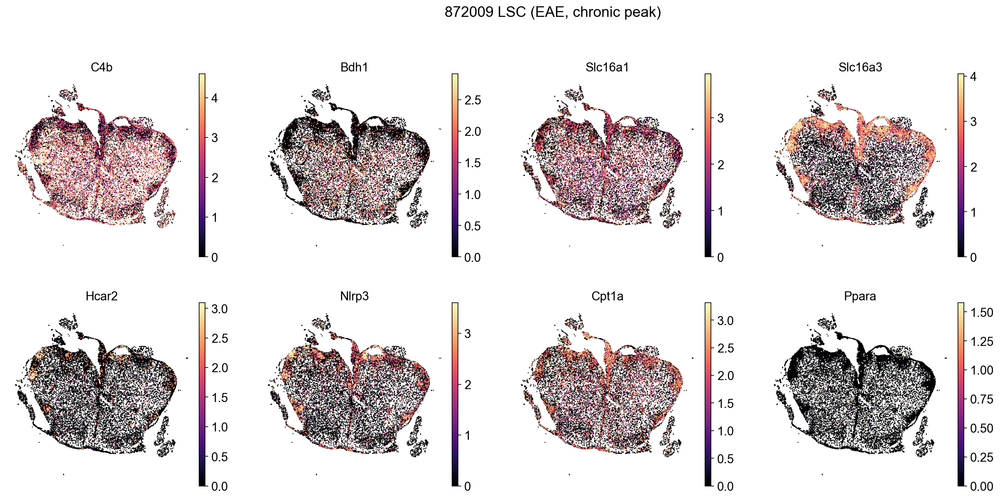

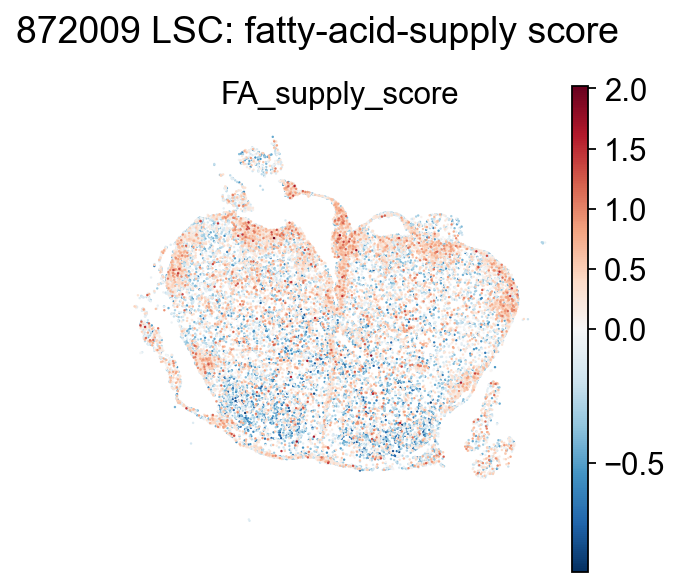

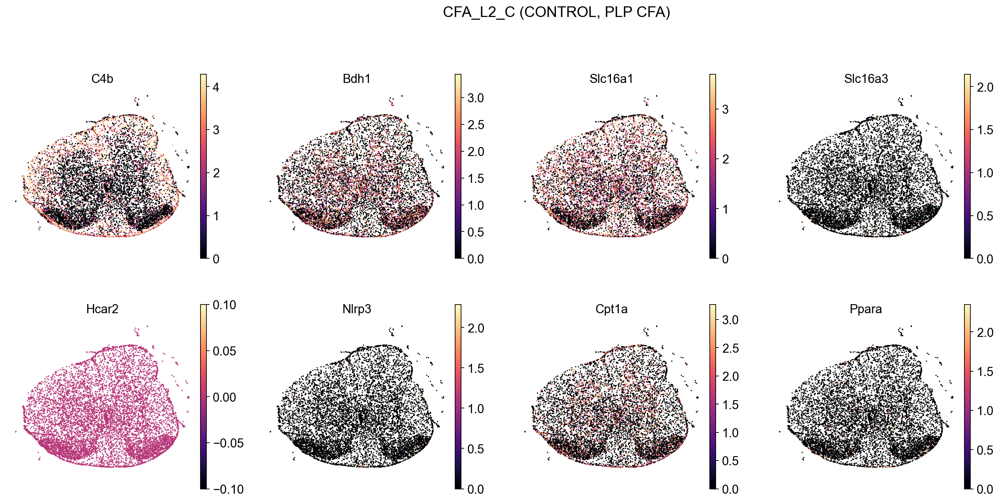

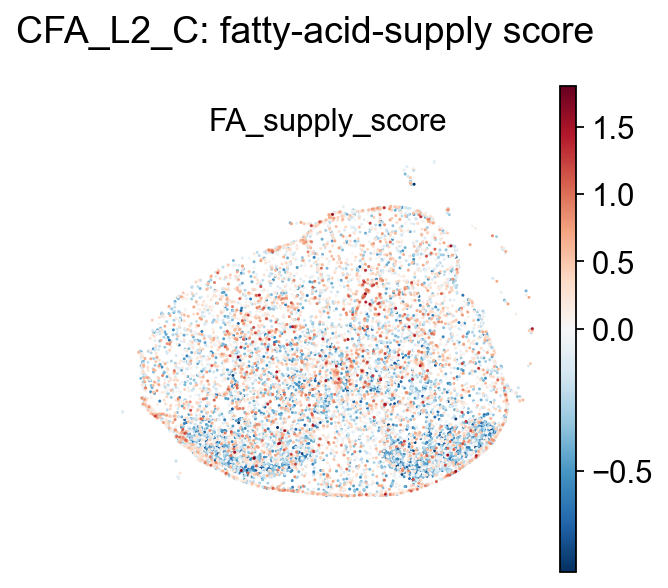

In [10]:
peak = meta[(meta.condition == "EAE") & meta.course.astype(str).str.contains("peak", case=False)].sort_values("n_cells", ascending=False).index[0]
ctrl = meta[meta.condition == "CONTROL"].sort_values("n_cells", ascending=False).index[0]
for s_ in [peak, ctrl]:
    sub = ad[ad.obs["sample_name"].astype(str) == str(s_)].copy()
    genes = [g for g in ["C4b", "Bdh1", "Slc16a1", "Slc16a3", "Hcar2", "Nlrp3", "Cpt1a", "Ppara"] if g in sub.var_names]
    sc.pl.spatial(sub, color=genes, spot_size=20, cmap="magma", vmax="p99", ncols=4, show=False); plt.suptitle(f"{s_} ({meta.loc[s_, 'condition']}, {meta.loc[s_, 'course']})", y=1.02); plt.show()
    sc.pl.spatial(sub, color=["FA_supply_score"], spot_size=20, cmap="RdBu_r", vcenter=0, show=False); plt.suptitle(f"{s_}: fatty-acid-supply score", y=1.02); plt.show()
    del sub

### Interpretation

**What the panel allows.** The 5K panel has no committed ketone enzyme, so this is a study of *Bdh1* (bidirectional), the monocarboxylate transporters, the BHB sensors and the fatty-acid-oxidation supply chain, in 107 samples and 27 cell types. Read with that limit in mind, the in-situ data give five clear answers.

**1. Ketogenic competence is astrocytic at baseline, not oligodendroglial or microglial.** In control tissue *Bdh1* is detected in 51 % of astrocytes, 45 % of newly formed oligodendrocytes, 29 % of ependymal cells, 27 % of neurons, 22 % of OPCs, 16 % of mature oligodendrocytes and endothelial cells and 8 % of microglia, and astrocytes also carry the highest β-oxidation chain (*Cpt1a* 41 %, *Hadhb* 50 %, *Echs1* 55 %, *Acaa2* 24 %) and the highest *Ppara* / *Ppargc1a*; their fatty-acid-supply score (0.31) is the highest of all cell types, followed by foamy myeloid cells (0.25) and DA astrocytes (0.18), with oligodendrocytes at zero and neurons at −0.27. Inside every cell type *Bdh1*⁺ cells are 1.3–3.8× enriched for the β-oxidation genes and for *Ppara* / *Ppargc1a* (oligodendrocytes: *Acaa2* 2.3×, *Cpt1a* 2.1×, *Ppara* 2.2×, *Ppargc1a* 2.4×; astrocytes ≈ 1.5× across the chain) and not for MCT4 or *Hcar2*, so *Bdh1* sits on the fatty-acid-oxidation, i.e. ketogenic, side of the reaction wherever it is expressed. MCT1 (*Slc16a1*) is oligodendroglial (40 %), endothelial (32 %) and astrocytic (31 %; 70 % of DA astrocytes); MCT4 (*Slc16a3*) is microglial (13 %); *Hcar2* (2 % of control microglia) and *Nlrp3* (20 %) are myeloid; SMCT2, *Ffar3*, *Ffar2*, *Fgf21* and *Klb* are at the detection floor.

**2. EAE does not switch on a ketogenic program in any cell type; it dismantles it near lesions.** *Bdh1* falls toward lesions in every cell type (astrocytes −0.33, DA astrocytes −0.49, endothelial −0.28, neurons −0.23, newly formed oligodendrocytes −0.22, OPCs −0.13 log-expression units between the 0–10 µm and >500 µm bins), *Acss2* falls toward lesions and in 13 cell types overall, *Ppargc1a* falls in 10 and *Ppara* in 5 (astrocytes −0.35, OPCs −0.75 log2), and the astrocytic β-oxidation chain thins toward lesions (*Cpt1a* −0.29, fatty-acid-supply score −0.19). Across EAE samples, astrocytic *Acss2* (ρ −0.49) and *Ppargc1a* (−0.38) fall with lesion burden. The exceptions are oligodendrocytes, in which EAE raises *Bdh1* modestly (+0.21 log2 in homeostatic, +0.20 in DA oligodendrocytes; per-sample *Bdh1* tracks lesion burden, ρ 0.39), and myeloid cells and DA oligodendrocytes, in which *Cpt1a* / *Cpt2* rise (microglia *Cpt1a* +0.73, DA oligodendrocytes +0.55 / +0.71, both increasing toward lesions and with lesion burden, ρ 0.4–0.6). *Bdh1* is flat across the disease course in astrocytes (1.2–1.4) and oligodendrocytes (0.35–0.50). The RR model shows every effect more strongly than the chronic model (e.g. astrocyte MCT1 +1.0 vs +0.3 log2, microglial *Bdh1* −0.72 vs −0.32).

**3. What EAE turns on is monocarboxylate transport.** MCT4 rises in 14 cell types (astrocytes +1.3, DA astrocytes +2.5, endothelial +1.7, microglia +1.0 log2) and toward lesions in all of them (DA oligodendrocytes +0.30, OPCs +0.32, endothelial +0.29, macrophages +0.29), and MCT1 rises in 10 (astrocytes +0.8, DA oligodendrocytes +0.6, newly formed oligodendrocytes +0.7, OPCs +0.4). Astrocytic MCT1 is the single ketone-related gene that best tracks the disease: it climbs from 0.7 in CFA controls to 1.5–2.1 at the RR peaks and returns to 0.9–1.3 in remission, and its per-sample level correlates with lesion fraction at ρ 0.68 (DA astrocytes 0.59, microglia 0.45). Endothelial MCT1 goes the other way (−0.33 toward lesions). So EAE re-wires lactate / ketone shuttling (astrocytes and myeloid cells export through MCT4, astrocytes and oligodendrocytes gain MCT1) without changing local ketone synthesis.

**4. The disease-associated oligodendrocyte is not a ketone-using state; the newly formed oligodendrocyte is.** Paired within 107 samples, DA oligodendrocytes have less *Bdh1* (−0.42 log2; higher in only 4 % of samples), less MCT1 (−0.21), less of the whole β-oxidation chain (*Cpt1c* −0.60, *Cpt2* −0.70, *Hadhb* −0.50, *Hadh* −0.41, *Echs1* −0.35, *Slc25a20* −0.44), less *Ppara* (−0.60), *Ppargc1a* (−1.3), *Pdk4* (−0.53) and *Acss2* (−0.69) than homeostatic oligodendrocytes, and more MCT4 (+1.2). *C4b*-high lineage cells show the same *Bdh1* / β-oxidation deficit with higher *Pdk4* (+0.77, 87 % of samples), MCT1 (+0.25) and *Acss2* (+0.46). Newly formed oligodendrocytes are the opposite: *Bdh1* +1.4 log2 (higher in 100 % of samples), *Cpt1a* +0.9, *Cpt1c* +0.7, *Slc25a20* +0.6, *Acss1* +0.6, MCT4 +1.8, MCT1 −1.0 and *Pdk4* −2.2 relative to mature oligodendrocytes: the remyelinating stage is the lineage's fatty-acid- and ketone-handling stage, in line with the progenitor ketolysis seen in the sorted Falcão cells. DA astrocytes likewise lose *Bdh1* (−0.34), *Acss1* (−1.2), *Hadhb* (−0.67), *Acaa2* (−0.85), *Ppara* (−1.0) and *Ppargc1a* (−0.93) and gain MCT1 (+1.2, 100 % of samples) and MCT4 (+2.5).

**5. BHB sensing belongs to myeloid cells, and those cells surround DA oligodendrocytes.** *Hcar2* is in 8 % of microglia, 13 % of activated myeloid cells and 20–21 % of proliferating microglia and infiltrating myeloid cells; *Nlrp3* in 22 % of microglia, 28 % of macrophages and 45 % of infiltrating myeloid cells; the two co-occur 1.5–1.9× more often than expected, and *Hcar2*⁺ myeloid cells are 1.9× enriched for *Nlrp3*, 2.4× for *Cd36* and 1.4× for *Lpl* and MCT4, i.e. the lipid-laden phagocyte. EAE raises microglial *Hcar2* four-fold (+2.1 log2; from 0.05 in controls to 0.27–0.47 at onset and peak, 0.16 in remission), *Ffar2* (+1.5), *Cpt1a* (+0.7) and MCT4 (+1.0) and lowers *Bdh1* (−0.6) and *Acss2* (−0.6); *Nlrp3* per cell is unchanged, its tissue-level rise is recruitment. Toward lesions, microglial *Hcar2* falls (0.26 → 0.06) while macrophage *Hcar2* rises (0.08 → 0.17), so the BHB-responsive cells at the lesion are infiltrating and activated myeloid cells, not resident microglia. The apparent *Hcar2* and *Nlrp3* "induction" in 12–15 non-myeloid cell types (up to +5 log2 in newly formed oligodendrocytes) is spill-over from these cells into neighbouring segments and should not be read as intrinsic. Spatially, DA oligodendrocytes have *fewer* *Bdh1*⁺ (0.82), *Cpt1a*⁺ (0.77) and *Bdh1*⁺*Cpt1a*⁺ (0.69) astrocytes and fewer MCT1⁺ endothelial cells (0.77) within 30 µm than homeostatic oligodendrocytes of the same sample, and *more* MCT4⁺ astrocytes (1.9), *Hcar2*⁺ (1.6) and *Nlrp3*⁺ (1.6) myeloid cells; all of this survives lesion-distance matching (0.82–0.90 and 1.2–1.5). Around *C4b*-high versus *C4b*-negative oligodendrocytes the astrocyte targets are neutral (0.9–1.0) while MCT4⁺ astrocytes (2.3; matched 1.75) and *Hcar2*⁺ / *Nlrp3*⁺ myeloid cells (1.7–1.8; matched 1.7) remain enriched. The DA oligodendrocyte niche is therefore lactate-rich and ketogenesis-poor.

**What this means for the central question.** At the transcript level the EAE spinal cord does not up-regulate local ketone production; the ketogenic-competent cells (astrocytes) lose *Bdh1*, PPARα / PGC1α and β-oxidation near lesions, and the DA oligodendrocyte is a lactate-exporting, lipid-importing cell rather than a ketone-consuming one. If BHB is beneficial in EAE, these data point to exogenous supply (diet, supplementation) rather than induced synthesis, and to two cellular targets: *Hcar2*⁺ / *Nlrp3*⁺ myeloid cells that accumulate around DA oligodendrocytes (anti-inflammatory signalling), and cells that gain MCT1 in disease (astrocytes, DA and newly formed oligodendrocytes) for import as fuel, with the newly formed oligodendrocyte as the lineage stage best equipped to use it. Confirming utilisation needs *Oxct1* / *Aacs* (a custom Xenium add-on or the nuclei object with whole-transcriptome data) and BHB measurements.

**Caveats.** No *Hmgcs2*, *Oxct1*, *Acat1*, *Aacs* or MCT2 on the panel; *Hcar2*, *Nlrp3*, *Fgf21*, *Klb*, SMCT2, *Ffar2* / *Ffar3* are near the detection floor and *Hcar2* / *Nlrp3* in non-myeloid segments are spill-over; *Bdh1* direction is inferred from its company, not measured; controls are 15 CFA-immunised animals; transcript abundance is not flux.